# Simple notebook examples

This tutorial covers toy examples on how to use breads to fit models to data by analytically marginalizing over linear parameters, enabling the evaluation of model probabilities without relying on computationally expensive (or even intractable) MCMC methods.
The first example demonstrates how to fit a simple linear model to data, while subsequent examples cover non-linear parameters, using the BREADS likelihood in an MCMC, noise scaling factor, and regularization (meaning prior) of the linear parameters.
The BREADS maths is validated below by comparing the results of the grid-based approach to a traditional MCMC sampling technique.

Import necessary modules from breads and packages

In [1]:
from breads.fit import fitfm, log_prob
from breads.instruments import Instrument
from breads.grid_search import grid_search
import numpy as np
import matplotlib.pyplot as plt
import emcee

/home/jruffio/anaconda3/envs/breads_2026/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Case 1: Fitting a line - Introduction to linear models

This section demonstrates how to fit a simple linear forward model (slope and intercept) to synthetic 1D data. It uses BREADS' fitfm to obtain analytic best-fit linear parameters and marginalized uncertainties. The outputs from BREADS are then validated by comparing them to an MCMC posterior computed with emcee.
Note: the noise is assumed to be Gaussian and uncorrelated, and the linear parameters are fitted without regularization (i.e., no priors on the slope and intercept). The noise model is accurate and does not require scaling in this example, but we will explore noise scaling in a later section.

First, we need to define our noise data (i.e., the "observations"), which consists of a simple linear trend with some noise.
BREADS uses instrument/data objects to store data, noise, and other relevant information. We will create a custom instrument instance and fill it manually with our synthetic data.

In [2]:
data_obj = Instrument() # Create a custom (empty for now) instrument instance to be filled namually later

np.random.seed(5)  # For reproducibility

slope = 2.0 # True slope of the linear trend, that we will try to estimate
intercept = 5 # True intercept of the linear trend, that we will try to estimate
noise_stddev = 1.0 # standard deviation of the Gaussian noise added to the data
my_wvs = np.linspace(0, 10, 20)  # Wavelengths from 0 to 10. But here this is just the x-axis for our linear trend.


# Fill the instrument instance with our synthetic data
data_obj.manual_data_entry(
    wavelengths=my_wvs,  # Wavelengths from 0 to 10
    data=slope * my_wvs + intercept + np.random.normal(0, noise_stddev, my_wvs.size),
    noise=np.ones_like(my_wvs) * noise_stddev,
    bad_pixels=np.ones_like(my_wvs)
)

Plotting the data with error bars and the true line to visualize the synthetic data we will be fitting.

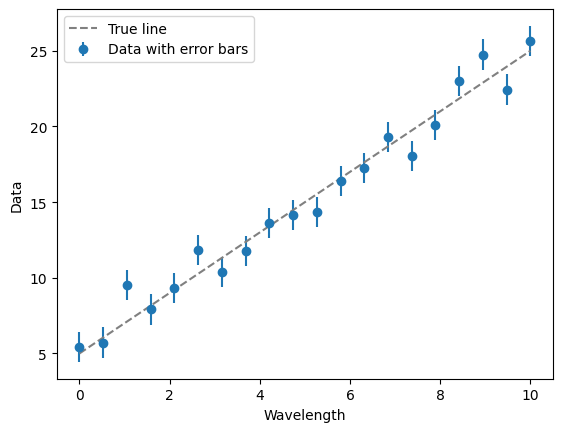

In [3]:
plt.figure()
plt.errorbar(my_wvs, data_obj.data, yerr=data_obj.noise, fmt='o', label='Data with error bars')
plt.plot(data_obj.wavelengths, slope * data_obj.wavelengths + intercept, label='True line', color='grey',
         linestyle='--')
plt.xlabel("Wavelength")
plt.ylabel("Data")
plt.legend()

Then, we need to define the forward model function.
The goal of this function is to return the data, forward model matrix M (because these are linear models), and noise vector for the linear model.
A linear trend is defined with two parameters: slope (m) and intercept (b). The model is linear in these two parameters; they will be the linear parameters to be fitted for. The matrix M will therefore have two columns.
We do not yet worry about the non-linear parameters here; they will be left empty.

The linear forward model function must return:

- d: Data as a 1d vector with bad pixels removed (and no nans)
- M: Linear model as a matrix of shape (Nd,Np) with bad pixels removed (no nans). Nd is the size of the data vector and Np (=2 here) is the number of linear parameters.
- s: Noise vector (standard deviation) as a 1d vector matching d.

See [templatefm](../api/breads.fm.templatefm.html#breads.fm.templatefm) (`breads.fm.templatefm`) for more information.

In [4]:
def linear_fm_func(nonlin_paras, data_obj: "Instrument", **fm_paras):
    """
    Build a linear forward model for a data object from an Instrument class.
    The linear parameters of the model are [slope, intercept].

    Parameters
    ----------
    nonlin_paras : array-like
        Non-linear parameters (not used in this simple linear model,but kept for consistency).
    data_obj : Instrument
        An instance of the Instrument class containing wavelengths and data.

    Returns
    -------
    d : np.ndarray
        The noisy data flattended.
    M : np.ndarray
        The design matrix for linear fitting (wavelengths and constant term).
    s : np.ndarray or None
        Uncertainties from instrument.noise (standard deviation).
    """

    # Flatten the data for 1D linear fit
    d = data_obj.data.flatten()
    x = data_obj.wavelengths.flatten()

    s = data_obj.noise.flatten()

    # Design matrix: linear term + constant
    M = np.vstack([x, np.ones_like(x)]).T

    return d, M, s

Given a data object and a forward model function, the [fitfm](../api/breads.fit.fitfm.html#breads.fit.fitfm) function can invert the linear least square model.
We will discuss marginalize_noise_scaling and scale_noise later; can be ignored for now.

In [5]:
results = fitfm(
            nonlin_paras=[],
            dataobj=data_obj,
            fm_func=linear_fm_func,
            fm_paras={},
            marginalize_noise_scaling=False, scale_noise=False
        )
bestfit_log_prob, log_prob_H0, rchi2, linparas, linparas_err = results

The best fit linear parameters (linparas) and their uncertainties (linparas_err) are printed below, along with the reduced chi-squared of the fit.

In [6]:
print("BREADS Slope (m):", linparas[0], "±", linparas_err[0])
print("BREADS Intercept (b):", linparas[1], "±", linparas_err[1])
print("Reduced chi2:", rchi2)

BREADS Slope (m): 1.950038181316302 ± 0.07367883976130073
BREADS Intercept (b): 5.297929868001825 ± 0.4309458036856674
Reduced chi2: 1.115073450987001


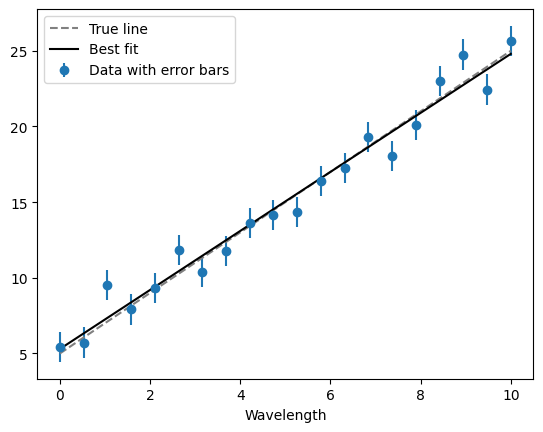

In [7]:
plt.figure()
model = linparas[0] * data_obj.wavelengths + linparas[1]
plt.errorbar(data_obj.wavelengths, data_obj.data, yerr=data_obj.noise, fmt='o', label='Data with error bars')
plt.plot(data_obj.wavelengths, slope * data_obj.wavelengths + intercept, label='True line', color='grey',
         linestyle='--')
plt.plot(data_obj.wavelengths, model, label='Best fit', color='black', linestyle='-')

plt.xlabel("Wavelength")
plt.legend()

Let's compare the BREADS uncertainties to those obtained from an MCMC sampling of the posterior distribution using emcee. The MCMC will sample the slope and intercept parameters, and we will compare the resulting posterior distributions to the BREADS best fit and uncertainties.

First we need to define a likelihood for the MCMC:

In [8]:
def log_likelihood_test(paras, data_obj):
    """
    Returns log-likelihood for a proposed mu using the Gaussian FM function.
    """
    a,b = paras  # extract scalar mu

    d,M,s = linear_fm_func([], data_obj)
    model = np.dot(M, [a,b])  # linear model prediction
    # The previous line is equivalent to:
    # model = a * data_obj.wavelengths + b  # linear model prediction

    # Compare model to observed data
    chi2 = np.sum(((d - model) / s) ** 2)

    # Log-likelihood
    return -0.5 * chi2

Now let's run the EMCEE

In [9]:
# MCMC setup
nwalkers = 50
nsteps = 1000

# Start walkers near the approximate mu
paras_init = np.array([0,0])
ndim = np.size(paras_init)
p0 = paras_init + 1e-2 * np.random.randn(nwalkers, ndim)
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_likelihood_test, args=[data_obj])

# Run MCMC
sampler.run_mcmc(p0, nsteps, progress=True)
samples = sampler.get_chain(flat=True)

100%|██████████| 1000/1000 [00:00<00:00, 1154.26it/s]


Plotting the posteriors. Making sure the BREADS uncertainties match the MCMC posteriors.

EMCEE Slope (m): 1.9481051976833883 ± 0.07377009839961789
EMCEE Intercept (b): 5.313805240959914 ± 0.4370898476411992


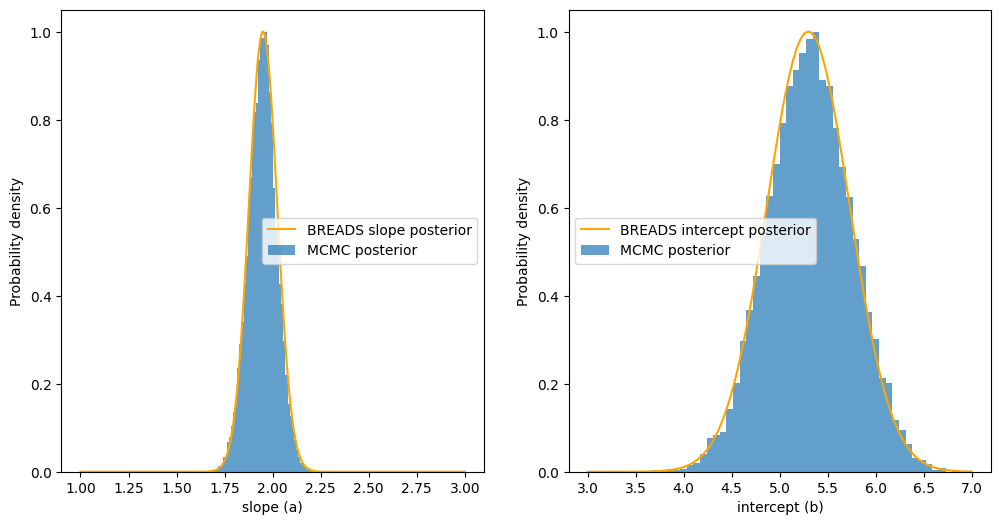

In [10]:
# Plot MCMC posterior as histogram
# Discard burn-in and extract chains
a_samples = samples[(nsteps//4*nwalkers)::, 0]
b_samples = samples[(nsteps//4*nwalkers)::, 1]
print("EMCEE Slope (m):", np.median(a_samples), "±", np.std(a_samples))
print("EMCEE Intercept (b):", np.median(b_samples), "±", np.std(b_samples))

# Compute histogram
hist_vals_a, bin_edges_a = np.histogram(a_samples, bins=50, density=True)
hist_vals_b, bin_edges_b = np.histogram(b_samples, bins=50, density=True)

# Normalize so the max is 1 (to match grid-search)
hist_vals_a /= np.max(hist_vals_a)
hist_vals_b /= np.max(hist_vals_b)

# Bin centers for plotting
bin_centers_a = 0.5 * (bin_edges_a[:-1] + bin_edges_a[1:])
bin_centers_b = 0.5 * (bin_edges_b[:-1] + bin_edges_b[1:])

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.bar(bin_centers_a, hist_vals_a, width=bin_edges_a[1] - bin_edges_a[0], alpha=0.7,label='MCMC posterior')
a_axis = np.linspace(slope-1, slope+1, 1000)
plt.plot(a_axis,np.exp(-(a_axis-linparas[0])**2/(2*linparas_err[0]**2)), label='BREADS slope posterior',color="orange")
plt.xlabel("slope (a)")
plt.ylabel("Probability density")
plt.legend()

plt.subplot(1,2,2)
plt.bar(bin_centers_b, hist_vals_b, width=bin_edges_b[1] - bin_edges_b[0], alpha=0.7,label='MCMC posterior')
b_axis = np.linspace(intercept-2, intercept+2, 1000)
plt.plot(b_axis,np.exp(-(b_axis-linparas[1])**2/(2*linparas_err[1]**2)), label='BREADS intercept posterior',color="orange")
plt.xlabel("intercept (b)")
plt.ylabel("Probability density")
plt.legend()

## Case 2: Non-linear parameters

In this section, we will show how to fit for non-linear parameters using BREADS. We will use a similar linear model as before but only keep the intercept (removing the slope for simplicity), but we will add a Gaussian feature to the data, which has a non-linear parameter corresponding to its center.

We will fit for the intercept, and position and amplitude of a Gaussian. The Gaussian can be thought of as a planet signal, and the intercept can be thought of as a linear parameter corresponding to the stellar flux.

The intercept and amplitude of the Gaussian are linear parameters
The center of the Gaussian is a non-linear parameter.

The Gaussian center will be fitted using a grid_search().  grid_search() computes the posterior probability of the model marginalized over the linear parameters for each value of the non-linear parameter in the grid. It also returns the best-fit linear parameters and their uncertainties for each value of the non-linear parameter in the grid.

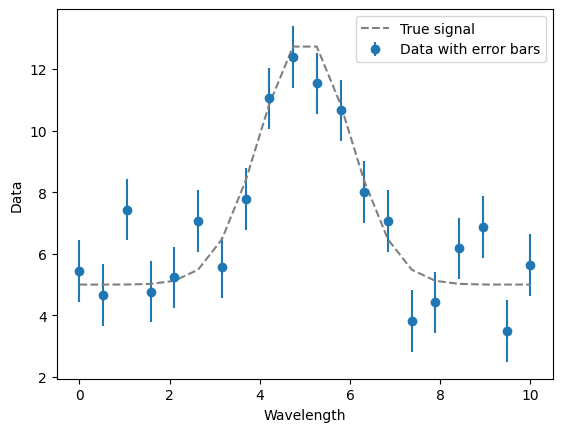

In [11]:
data_obj = Instrument()  # Create a custom instrument instance to be filled manually

np.random.seed(5)  # For reproducibility

intercept = 5
noise_stddev = 1.0
gauss_amplitude = 8.0 # The amplitude of the Gaussian feature.
gauss_center = 5.0 # The center of the Gaussian feature.
gauss_width = 1.0 # The width of the Gaussian feature. This is fixed for simplicity, but it could also be a non-linear parameter.
# Wavelengths from 0 to 10. But here this is just the x-axis for our linear trend.
my_wvs = np.linspace(0, 10,20)
gauss0 = gauss_amplitude * np.exp(-(my_wvs - gauss_center) ** 2 / (2 * gauss_width ** 2))

data_obj.manual_data_entry(
    wavelengths=my_wvs,  # Wavelengths from 0 to 10
    data= np.full(my_wvs.shape,intercept) + gauss0 + np.random.normal(0, noise_stddev, my_wvs.size),
    noise=np.ones_like(my_wvs) * noise_stddev,
    bad_pixels=np.ones_like(my_wvs)
)

plt.figure()
plt.errorbar(my_wvs, data_obj.data, yerr=data_obj.noise, fmt='o', label='Data with error bars')
plt.plot(data_obj.wavelengths, np.full(my_wvs.shape,intercept) + gauss0, label='True signal', color='grey',linestyle='--')
plt.xlabel("Wavelength")
plt.ylabel("Data")
plt.legend()

Let's define the new forward model function with the Gaussian feature. The linear parameters of the model are [gauss_amplitude, intercept], and the non-linear parameter of the model is [gauss_center].

In [12]:
def intro_nonlin_fm(nonlin_paras, data_obj: "Instrument", gauss_width=None):
    """
    Build a linear forward model for case 2:
    Fitting for intercept, and position and amplitude of a Gaussian (accurate noise model without noise scaling, no regularization)
    The gaussian can be thought of as a planet signal, and the intercept can be thought of as a linear parameter corresponding to the stellar flux.

    The linear parameters of the model are [gauss_amplitude, slope].
    The non-linear parameter of the model are [gauss_center].

    Parameters
    ----------
    nonlin_paras : array-like
        Non-linear parameters: [gauss_center].
    data_obj : Instrument
        An instance of the Instrument class containing wavelengths and data.
    gauss_width : float
            The width of the Gaussian. This is fixed for simplicity, but it could also be a non-linear parameter.

    Returns
    -------
    d : np.ndarray
        The noisy data flattended.
    M : np.ndarray
        The design matrix for linear fitting (wavelengths and constant term).
    s : np.ndarray or None
        Uncertainties from instrument.noise (standard deviation).
    """

    # Flatten the data for 1D linear fit
    y = data_obj.data.flatten()
    x = data_obj.wavelengths.flatten()
    s = data_obj.noise.flatten()

    gauss_center = nonlin_paras[0]
    col0 = np.exp(-(x - gauss_center) ** 2 / (2 * gauss_width ** 2))

    # Design matrix: linear term + constant
    M = np.vstack([col0, np.ones_like(x)]).T

    return y, M, s

Before fitting for gauss_center, let's fix it and see how to fit for gauss_amplitude and intercept using BREADS. We just set nonlin_paras=[gauss_center].

In [13]:
# If we already know gauss_center, we can simply fit for the gaussian amplitude and intercept.
results = fitfm(
    nonlin_paras=[gauss_center],
    dataobj=data_obj,
    fm_func=intro_nonlin_fm,
    fm_paras={'gauss_width':gauss_width},
    marginalize_noise_scaling=False, scale_noise=False
)
bestfit_log_prob, log_prob_H0, rchi2, linparas, linparas_err = results

print("BREADS gaussian amplitude (fixed gauss_center):", linparas[0], "±", linparas_err[0])
print("BREADS Intercept (fixed gauss_center):", linparas[1], "±", linparas_err[1])
print("Reduced chi2 (fixed gauss_center):", rchi2)

BREADS gaussian amplitude (fixed gauss_center): 7.0247489748018 ± 0.6691175079003598
BREADS Intercept (fixed gauss_center): 5.280356971178916 ± 0.27456910271044105
Reduced chi2 (fixed gauss_center): 1.0318466307191767


Now, we also want the posterior on gauss_center. We can do this by running a grid search over gauss_center, which effectively runs fitfm for each value of gauss_center in the grid, and returns the log probability and best-fit linear parameters for each value of gauss_center.

In the outputs of grid_search:

- linparas is an array of shape (len(gauss_center_grid), N_linpara) containing the best-fit linear parameters for each value of gauss_center in the grid.
- linparas_err is an array of shape (len(gauss_center_grid), N_linpara) containing the uncertainties of the best-fit linear parameters for each value of gauss_center in the grid.

See [grid_search](../api/breads.grid_search.grid_search.html#breads.grid_search.grid_search) for more information.

See [get_err_from_posterior](../api/breads.utils.get_err_from_posterior.html#breads.utils.get_err_from_posterior) for more information on how to get uncertainties from the posterior distribution.

BREADS gauss_center (left/right uncertainties): 4.97979797979798 - 0.1434800003103236 + 0.12297571398138452


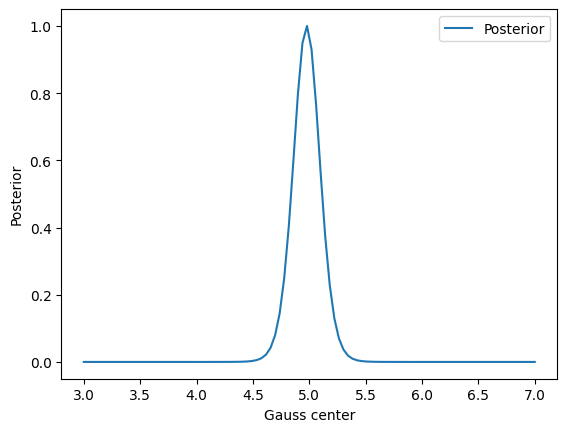

In [14]:
gauss_center_grid = np.linspace(gauss_center-2, gauss_center+2, 100)

# grid_search effectively runs fitfm for each value of gauss_center in the grid, and returns the log probability and best-fit linear parameters for each value of gauss_center.
bestfit_log_prob, _, rchi2, linparas, linparas_err = grid_search(
    para_vecs=[gauss_center_grid],
    dataobj=data_obj,
    fm_func=intro_nonlin_fm,
    fm_paras={"gauss_width": gauss_width},
    numthreads=None,
    bounds=None
)

where_max_prob = np.argmax(bestfit_log_prob)

# Taking the exponential of log probabilities to get the actual probabilities (up to a normalization constant).
prob = np.exp(bestfit_log_prob - np.max(bestfit_log_prob))

# get_err_from_posterior() takes in a grid of parameter values and their corresponding probabilities, and returns the best-fit parameter value along with the left and right uncertainties based on the cumulative distribution of the posterior.
from breads.utils import get_err_from_posterior
best_fit, left_err, right_err = get_err_from_posterior(gauss_center_grid, prob)
print("BREADS gauss_center (left/right uncertainties):", best_fit, "-", left_err, "+", right_err)

plt.figure()
plt.plot(gauss_center_grid, prob, label="Posterior")
plt.xlabel("Gauss center")
plt.ylabel("Posterior")
plt.legend()

We can now compare the BREADS-derived posterior for the Gaussian center to the MCMC posterior for the same parameter. The MCMC will sample all three parameters (gauss_center, gauss_amplitude, and intercept), while the grid search only samples gauss_center and marginalizes over the linear parameters. Therefore, the BREADS posterior for gauss_center should match the MCMC posterior for gauss_center, while the BREADS best-fit linear parameters are not directly comparable to the MCMC posteriors for the linear parameters since they are not marginalized over gauss_center in the grid search.

First, let's define the likelihood function for the MCMC, which will be similar to the one we defined for the linear case, but now it will include the non-linear parameter gauss_center and the corresponding model with the Gaussian feature.

In [15]:
def log_likelihood_case2(paras, data_obj):
    """
    Returns log-likelihood for case 2.
    We are here fitting for 3 parameters: gauss_center, gauss_amplitude, and intercept.
    gauss_center is a non-linear parameters, while gauss_amplitude and intercept are linear parameters.
    Unlike in BREADS, they are all treated the same in the MCMC.
    """
    gauss_center,gauss_amplitude,intercept = paras

    d,M,s = intro_nonlin_fm([gauss_center], data_obj,gauss_width=gauss_width)
    model = np.dot(M, [gauss_amplitude,intercept])  # linear model prediction

    # Log-likelihood
    log_like = -0.5 * np.sum(((d - model) / s) ** 2)

    return log_like

Let's run the MCMC now:

In [16]:
# MCMC setup
nwalkers = 50
nsteps = 1000

# Start walkers
paras_init = np.array([gauss_center,gauss_amplitude,intercept])
ndim = np.size(paras_init)
p0 = paras_init + 1e-2 * np.random.randn(nwalkers, ndim)
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_likelihood_case2, args=[data_obj])

# Run MCMC
sampler.run_mcmc(p0, nsteps, progress=True)
samples = sampler.get_chain(flat=True)

100%|██████████| 1000/1000 [00:01<00:00, 933.68it/s]


And plot the results:

EMCEE gaussian center: 4.982112822375332 ± 0.10767389699660625
EMCEE gaussian amplitude: 6.989300065605137 ± 0.6634902405042186
EMCEE Intercept: 5.294662550611401 ± 0.27621675666043105


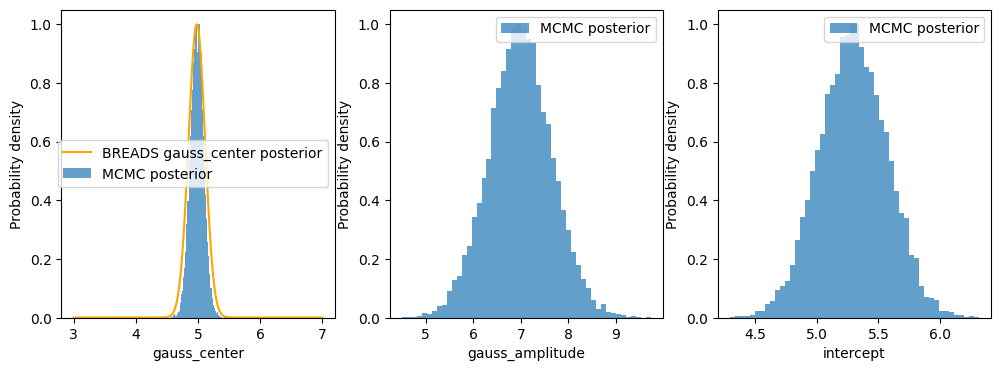

In [17]:
# Plot MCMC posterior as histogram
# Discard burn-in and extract chains
gauss_center_samples = samples[(nsteps//4*nwalkers)::, 0]
gauss_ampl_samples = samples[(nsteps//4*nwalkers)::, 1]
intercept_samples = samples[(nsteps//4*nwalkers)::, 2]
print("EMCEE gaussian center:", np.median(gauss_center_samples), "±", np.std(gauss_center_samples))
print("EMCEE gaussian amplitude:", np.median(gauss_ampl_samples), "±", np.std(gauss_ampl_samples))
print("EMCEE Intercept:", np.median(intercept_samples), "±", np.std(intercept_samples))

# Compute histogram
hist_vals_gauss_center,bin_edges_gauss_center = np.histogram(gauss_center_samples, bins=50, density=True)
hist_vals_gauss_ampl,bin_edges_gauss_ampl = np.histogram(gauss_ampl_samples, bins=50, density=True)
hist_vals_intercept,bin_edges_intercept = np.histogram(intercept_samples, bins=50, density=True)

# Normalize so the max is 1 (to match grid-search)
hist_vals_gauss_center /= np.max(hist_vals_gauss_center)
hist_vals_gauss_ampl /= np.max(hist_vals_gauss_ampl)
hist_vals_intercept /= np.max(hist_vals_intercept)

# Bin centers for plotting
bin_centers_gauss_center = 0.5 * (bin_edges_gauss_center[:-1] + bin_edges_gauss_center[1:])
bin_centers_gauss_ampl = 0.5 * (bin_edges_gauss_ampl[:-1] + bin_edges_gauss_ampl[1:])
bin_centers_intercept = 0.5 * (bin_edges_intercept[:-1] + bin_edges_intercept[1:])

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.bar(bin_centers_gauss_center, hist_vals_gauss_center, width=bin_edges_gauss_center[1] - bin_edges_gauss_center[0], alpha=0.7,label='MCMC posterior')
gauss_center_axis = np.linspace(gauss_center-2, gauss_center+2, 1000)
plt.plot(gauss_center_axis,np.exp(-(gauss_center_axis-best_fit)**2/(2*((left_err+right_err)/2)**2)), label='BREADS gauss_center posterior',color="orange")
plt.xlabel("gauss_center")
plt.ylabel("Probability density")
plt.legend()

plt.subplot(1,3,2)
plt.bar(bin_centers_gauss_ampl, hist_vals_gauss_ampl, width=bin_edges_gauss_ampl[1] - bin_edges_gauss_ampl[0], alpha=0.7,label='MCMC posterior')
plt.xlabel("gauss_amplitude")
plt.ylabel("Probability density")
plt.legend()

plt.subplot(1,3,3)
plt.bar(bin_centers_intercept, hist_vals_intercept, width=bin_edges_intercept[1] - bin_edges_intercept[0], alpha=0.7,label='MCMC posterior')
plt.xlabel("intercept")
plt.ylabel("Probability density")
plt.legend()

## Using BREADS' marginalized probablity in a MCMC

We can also use the breads.fit.log_prob() function in an MCMC sampler. log_prob() simply wraps around fitfm(), but only return the log probability. The major difference in using BREADS' log_prob() (instead of the MCMC likelihood defined previously) is that we are fitting for a single parameter (gauss_center), instead of 3 parameters in the previous MCMC (gauss_center, gauss_amplitude, and intercept). BREADS takes care of marginalizing over the linear parameters (gauss_amplitude and intercept) on the fly.
Note that in this demonstration, it might not be numerically worth it to use BREADS, but the advantage of this method comes when fitting for 100s or 1000s of linear parameters, which cannot be fitted inside an MCMC.

In [18]:
# Here is how it can be done:
nwalkers = 50
nsteps = 100

# Start walkers
fm_paras = {'gauss_width': gauss_width}
paras_init = np.array([gauss_center])
ndim = np.size(paras_init)
p0 = paras_init + 1e-2 * np.random.randn(nwalkers, ndim)

# log_prob si a function, which is imported as: from breads.fit import log_prob
# It wraps around fitfm() and only returns the log probability.
# The args are the same as for fitfm().
sampler_BREADS_like = emcee.EnsembleSampler(nwalkers, ndim, log_prob,
                                            args = [data_obj, intro_nonlin_fm, fm_paras, None, None, True, False])

sampler_BREADS_like.run_mcmc(p0, nsteps, progress=True)
samples_BREADS_like = sampler_BREADS_like.get_chain(flat=True)
gauss_center_samples_BREADS_like = samples_BREADS_like[(nsteps//4*nwalkers)::, 0]

print("EMCEE (with BREADS like) gaussian center:", np.median(gauss_center_samples_BREADS_like), "±", np.std(gauss_center_samples_BREADS_like))


100%|██████████| 100/100 [00:00<00:00, 140.78it/s]

EMCEE (with BREADS like) gaussian center: 4.9854114937047544 ± 0.11826877800423959


## Case 3: Noise scaling factor

In the previous examples, we assumed that the noise is well known and accurately represented by the noise vector in the data object. However, in some cases, the noise might not be well known, and it might be necessary to introduce a "noise scaling factor" to account for this. This is common in high-contrast imaging, where the noise is often underestimated. In this case, we can simply rescale the noise by a "noise scaling factor", which is the sqrt of the reduced chi2 of the fit. This allows us to correct for the underestimated noise and obtain more accurate uncertainties on the fitted parameters.

First, we will look at the case where we do not marginalize over the noise scaling factor, but simply rescale everything. Then, we will show what happens when the noise is marginalized over as well. Spoiler alert: marginalizing of the noise scaling factor is not really necessary since the noise scaling factor is typically very well constrained by the data.

As before, we first define the data object, but this time we will underestimate the noise by a factor of 5 in data_obj, meaning that the true noise is 5 times larger than what is represented in the data object. This should lead to a reduced chi2 of ~25 if we do not rescale the noise.

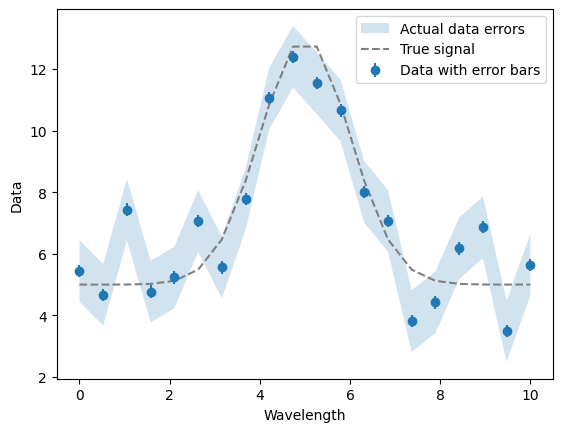

In [19]:
data_obj = Instrument()  # Create a custom instrument instance to be filled manually

np.random.seed(5)  # For reproducibility

intercept = 5
noise_stddev = 1.0
gauss_amplitude = 8.0
gauss_center = 5.0
gauss_width = 1.0
# Wavelengths from 0 to 10. But here this is just the x-axis for our linear trend.
my_wvs = np.linspace(0, 10,20)
gauss0 = gauss_amplitude * np.exp(-(my_wvs - gauss_center) ** 2 / (2 * gauss_width ** 2))

data_obj.manual_data_entry(
    wavelengths=my_wvs,  # Wavelengths from 0 to 10
    data= np.full(my_wvs.shape,intercept) + gauss0 + np.random.normal(0, noise_stddev, my_wvs.size),
    noise=np.ones_like(my_wvs) * noise_stddev/5., # This models the case where the noise is underestimated by a factor of 5. The fit should find a noise scaling factor of ~5 to compensate for this.
    bad_pixels=np.ones_like(my_wvs)
)

plt.figure()
plt.errorbar(my_wvs, data_obj.data, yerr=data_obj.noise, fmt='o', label='Data with error bars')
plt.fill_between(my_wvs, data_obj.data -noise_stddev, data_obj.data +noise_stddev, alpha=0.2, label='Actual data errors')
plt.plot(data_obj.wavelengths, np.full(my_wvs.shape,intercept) + gauss0, label='True signal', color='grey',linestyle='--')
plt.xlabel("Wavelength")
plt.ylabel("Data")
plt.legend()

We do not need to redefine the forward model function, since the model is the same as in case 2, we are just changing the noise. We will simply reuse the same forward model function as in case 2.

Below, we show the results of fitting for gauss_center without rescaling the noise (scale_noise=False). The uncertainties on the linear parameters are much smaller than they should be, and the reduced chi2 is much larger than 1, indicating a poor fit.

In [20]:
# Fitting without noise rescaling scale_noise=False will lead to much smaller uncertainties on the linear parameters, and a much larger reduced chi2.
results = fitfm(
    nonlin_paras=[gauss_center],
    dataobj=data_obj,
    fm_func=intro_nonlin_fm,
    fm_paras={'gauss_width':gauss_width},
    marginalize_noise_scaling=False, scale_noise=False
)
bestfit_log_prob, log_prob_H0, rchi2, linparas, linparas_err = results

print("BREADS gaussian amplitude (no noise scaling):", linparas[0], "±", linparas_err[0])
print("BREADS Intercept (no noise scaling):", linparas[1], "±", linparas_err[1])
print("Reduced chi2 (no noise scaling):", rchi2)

BREADS gaussian amplitude (no noise scaling): 7.024748974801803 ± 0.13382350158007195
BREADS Intercept (no noise scaling): 5.280356971178917 ± 0.0549138205420882
Reduced chi2 (no noise scaling): 25.79616576797941


Then, we can set scale_noise=True to enable rescaling of the noise. This will lead to more accurate uncertainties on the linear parameters.

Note: rchi2 is the reduced chi2 of the fit with the original noise (i.e., without rescaling) whether or not scale_noise is true or false. The noise scaling factor is sqrt(rchi2), which is the factor by which the noise should be rescaled to achieve a reduced chi2 of 1.

In [21]:
# We can correct for this by enabling scale_noise=True:
results = fitfm(
    nonlin_paras=[gauss_center],
    dataobj=data_obj,
    fm_func=intro_nonlin_fm,
    fm_paras={'gauss_width':gauss_width},
    marginalize_noise_scaling=False, scale_noise=True
)
bestfit_log_prob, log_prob_H0, rchi2, linparas, linparas_err = results
BREADS_noise_scaling = np.sqrt(rchi2)

print("BREADS gaussian amplitude (WITH noise scaling):", linparas[0], "±", linparas_err[0])
print("BREADS Intercept (WITH noise scaling):", linparas[1], "±", linparas_err[1])
print("Reduced chi2:", rchi2)

BREADS gaussian amplitude (WITH noise scaling): 7.024748974801803 ± 0.6796885734029403
BREADS Intercept (WITH noise scaling): 5.280356971178917 ± 0.27890688783109135
Reduced chi2: 25.79616576797941


Below, we derive the posterior for gauss_center with noise rescaling enabled.

BREADS gauss_center (left/right uncertainties): 4.97979797979798 - 0.1434800003103236 + 0.12297571398138452


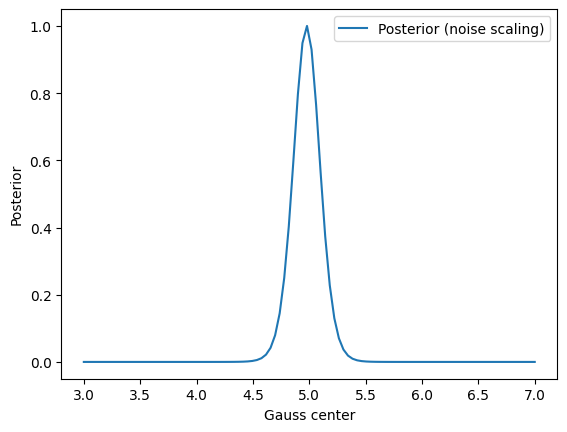

In [22]:
gauss_center_grid = np.linspace(gauss_center-2, gauss_center+2, 100)

bestfit_log_prob, _, rchi2, linparas, linparas_err = grid_search(
    para_vecs=[gauss_center_grid],
    dataobj=data_obj,
    fm_func=intro_nonlin_fm,
    fm_paras={"gauss_width": gauss_width},
    numthreads=None,
    bounds=None,
    marginalize_noise_scaling=False, scale_noise=True
)

where_max_prob = np.argmax(bestfit_log_prob)

prob_noise_scaling = np.exp(bestfit_log_prob - np.max(bestfit_log_prob))
from breads.utils import get_err_from_posterior
best_fit, left_err, right_err = get_err_from_posterior(gauss_center_grid, prob_noise_scaling)
print("BREADS gauss_center (left/right uncertainties):", best_fit, "-", left_err, "+", right_err)

plt.figure()
plt.plot(gauss_center_grid, prob_noise_scaling, label="Posterior (noise scaling)")
plt.xlabel("Gauss center")
plt.ylabel("Posterior")
plt.legend()

In theory, the noise rescaling implemented previously is not statistically rigorous, since it does not account for the uncertainty in the noise scaling factor. A more rigorous approach would be to marginalize over the noise scaling factor, which is equivalent to assuming a Jeffreys prior on the noise scaling factor and integrating it out. This is implemented in BREADS by setting marginalize_noise_scaling=True in fitfm() or grid_search(). Below, we show how to do this and compare the results to the case where we simply rescale the noise without marginalization.

Note: this only works without regularization. Also, linparas and linparas_err WON'T be marginalized over the noise scaling factor in all cases. The noise rescaling marginalization only affects the bestfit_log_prob output to derive the posteriors of non-linear parameters.

In [23]:
gauss_center_grid = np.linspace(gauss_center - 2, gauss_center + 2, 100)

bestfit_log_prob, _, rchi2, linparas, linparas_err = grid_search(
    para_vecs=[gauss_center_grid],
    dataobj=data_obj,
    fm_func=intro_nonlin_fm,
    fm_paras={"gauss_width": gauss_width},
    numthreads=None,
    bounds=None,
    marginalize_noise_scaling=True, scale_noise=False
)

where_max_prob = np.argmax(bestfit_log_prob)

prob_marginalized_noise_scaling = np.exp(bestfit_log_prob - np.max(bestfit_log_prob))
from breads.utils import get_err_from_posterior

best_fit, left_err, right_err = get_err_from_posterior(gauss_center_grid, prob_marginalized_noise_scaling)
print("BREADS gauss_center (marginalize_noise_scaling; left/right uncertainties):", best_fit, "-", left_err, "+", right_err)

BREADS gauss_center (marginalize_noise_scaling; left/right uncertainties): 4.97979797979798 - 0.1397901983260832 + 0.11931285562105298


In practice, the noise scaling factor is often very well constrained by the data, and the difference between simply rescaling the noise and marginalizing over the noise scaling factor is often negligible. However, in cases where the noise scaling factor is not well constrained, marginalizing over it can lead to more accurate posteriors for the non-linear parameters.

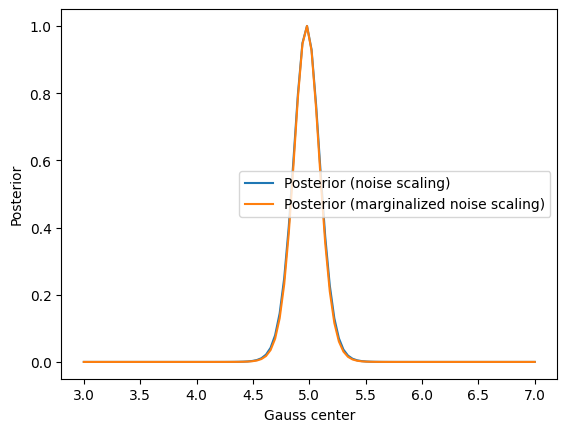

In [24]:
plt.figure()
plt.plot(gauss_center_grid, prob_noise_scaling, label="Posterior (noise scaling)")
plt.plot(gauss_center_grid, prob_marginalized_noise_scaling, label="Posterior (marginalized noise scaling)")
plt.xlabel("Gauss center")
plt.ylabel("Posterior")
plt.legend()

Now, let's compare the BREADS posteriors for gauss_center to the MCMC posterior for gauss_center.

In [25]:
def log_likelihood_case3(paras, data_obj):
    """
    Returns log-likelihood for case 3.
    Testing marginalization over noise scaling factor.
    """
    gauss_center,gauss_amplitude,intercept,noise_scaling = paras
    if noise_scaling <0:
        return -np.inf  # We don't want negative noise scaling factors.

    d,M,s = intro_nonlin_fm([gauss_center], data_obj,gauss_width=gauss_width)
    model = np.dot(M, [gauss_amplitude,intercept])  # linear model prediction

    s_scaled = s*noise_scaling

    # We need to include the penalty for the noise scaling factor in the likelihood, since it is a free parameter that can make the likelihood arbitrarily high by making the noise very large.
    log_like = -0.5 * np.sum(((d - model) / s_scaled) ** 2)- np.sum(np.log(s_scaled))  # The second term is the penalty for the noise scaling factor, which comes from the normalization of the Gaussian likelihood.

    # Log-likelihood
    return log_like

In [26]:
# MCMC setup
nwalkers = 50
nsteps = 1000

# Start walkers
paras_init = np.array([gauss_center,gauss_amplitude,intercept,5])
ndim = np.size(paras_init)
p0 = paras_init + 1e-2 * np.random.randn(nwalkers, ndim)
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_likelihood_case3, args=[data_obj])

# Run MCMC
sampler.run_mcmc(p0, nsteps, progress=True)
samples = sampler.get_chain(flat=True)

# Plot MCMC posterior as histogram
# Discard burn-in and extract chains
gauss_center_samples = samples[(nsteps//4*nwalkers)::, 0]
gauss_ampl_samples = samples[(nsteps//4*nwalkers)::, 1]
intercept_samples = samples[(nsteps//4*nwalkers)::, 2]
noise_scaling_samples = samples[(nsteps//4*nwalkers)::, 3]
print("EMCEE gaussian center:", np.median(gauss_center_samples), "±", np.std(gauss_center_samples))
print("EMCEE gaussian amplitude:", np.median(gauss_ampl_samples), "±", np.std(gauss_ampl_samples))
print("EMCEE Intercept:", np.median(intercept_samples), "±", np.std(intercept_samples))
print("EMCEE noise scaling factor:", np.median(noise_scaling_samples), "±", np.std(noise_scaling_samples))

100%|██████████| 1000/1000 [00:01<00:00, 802.96it/s]

EMCEE gaussian center: 4.982339980267529 ± 0.12865713799550038
EMCEE gaussian amplitude: 7.026828776378179 ± 0.8159137361073725
EMCEE Intercept: 5.24947068173965 ± 0.3294527471067003
EMCEE noise scaling factor: 5.768357774606423 ± 1.1145648686239076


Plotting the final posteriors for all parameters, including the noise scaling factor. The MCMC posterior for gauss_center should match the BREADS posterior for gauss_center with noise scaling/marginalization enabled.

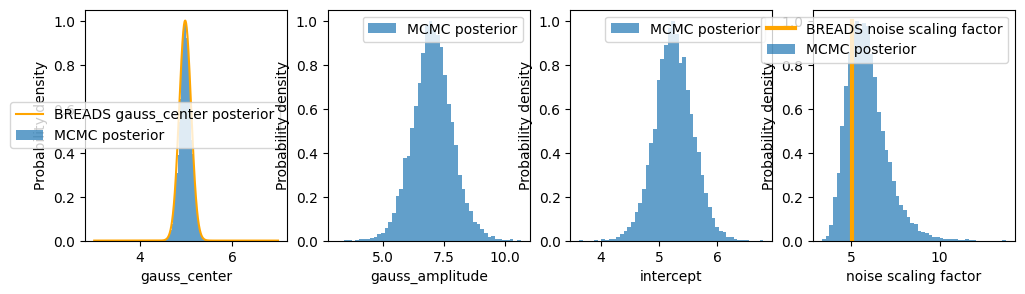

In [27]:
# Compute histogram
hist_vals_gauss_center,bin_edges_gauss_center = np.histogram(gauss_center_samples, bins=50, density=True)
hist_vals_gauss_ampl,bin_edges_gauss_ampl = np.histogram(gauss_ampl_samples, bins=50, density=True)
hist_vals_intercept,bin_edges_intercept = np.histogram(intercept_samples, bins=50, density=True)
hist_vals_noise_scaling,bin_edges_noise_scaling = np.histogram(noise_scaling_samples, bins=50, density=True)

# Normalize so the max is 1 (to match grid-search)
hist_vals_gauss_center /= np.max(hist_vals_gauss_center)
hist_vals_gauss_ampl /= np.max(hist_vals_gauss_ampl)
hist_vals_intercept /= np.max(hist_vals_intercept)
hist_vals_noise_scaling /= np.max(hist_vals_noise_scaling)

# Bin centers for plotting
bin_centers_gauss_center = 0.5 * (bin_edges_gauss_center[:-1] + bin_edges_gauss_center[1:])
bin_centers_gauss_ampl = 0.5 * (bin_edges_gauss_ampl[:-1] + bin_edges_gauss_ampl[1:])
bin_centers_intercept = 0.5 * (bin_edges_intercept[:-1] + bin_edges_intercept[1:])
bin_centers_noise_scaling = 0.5 * (bin_edges_noise_scaling[:-1] + bin_edges_noise_scaling[1:])

plt.figure(figsize=(12,3))
plt.subplot(1,4,1)
plt.bar(bin_centers_gauss_center, hist_vals_gauss_center, width=bin_edges_gauss_center[1] - bin_edges_gauss_center[0], alpha=0.7,label='MCMC posterior')
gauss_center_axis = np.linspace(gauss_center-2, gauss_center+2, 1000)
plt.plot(gauss_center_axis,np.exp(-(gauss_center_axis-best_fit)**2/(2*((left_err+right_err)/2)**2)), label='BREADS gauss_center posterior',color="orange")
plt.xlabel("gauss_center")
plt.ylabel("Probability density")
plt.legend()

plt.subplot(1,4,2)
plt.bar(bin_centers_gauss_ampl, hist_vals_gauss_ampl, width=bin_edges_gauss_ampl[1] - bin_edges_gauss_ampl[0], alpha=0.7,label='MCMC posterior')
plt.xlabel("gauss_amplitude")
plt.ylabel("Probability density")
plt.legend()

plt.subplot(1,4,3)
plt.bar(bin_centers_intercept, hist_vals_intercept, width=bin_edges_intercept[1] - bin_edges_intercept[0], alpha=0.7,label='MCMC posterior')
plt.xlabel("intercept")
plt.ylabel("Probability density")
plt.legend()

plt.subplot(1,4,4)
plt.bar(bin_centers_noise_scaling, hist_vals_noise_scaling, width=bin_edges_noise_scaling[1] - bin_edges_noise_scaling[0], alpha=0.7,label='MCMC posterior')
plt.plot([BREADS_noise_scaling,BREADS_noise_scaling],[0,1], label='BREADS noise scaling factor', color="orange",linewidth=3)
plt.xlabel("noise scaling factor")
plt.ylabel("Probability density")
plt.legend()

## Case 4: Regularization of linear parameters

In this section, we will show how to include regularization on the linear parameters in BREADS. Regularization is a way to include prior information on the linear parameters. Regularization and prior are synonymous. Assuming Gaussian noise and Gaussian priors, the regularization can be included by adding some extra terms to the data vector, the model matrix and the error vector.

In BREADS, the regularization is defined by a mean (d_reg) and a standard deviation (s_reg) for each linear parameter. Parameters without regularization are set to np.nan. fitfm() manages the bookkeeping accordingly.

Once again starting with the data object. We are increasing the noise in this case to better illustrate the effect of regularization. With low noise, the regularization won't have much effect since the data is already very constraining.

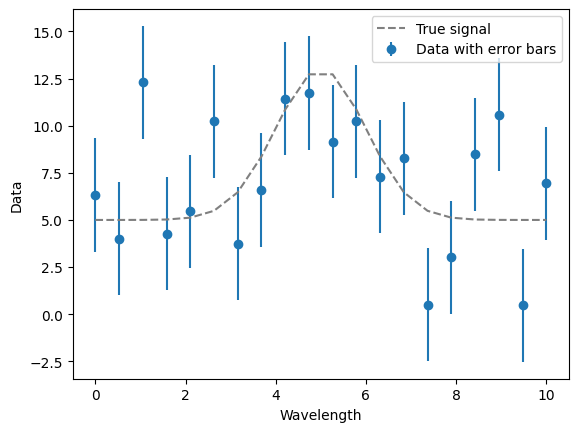

In [28]:
data_obj = Instrument()  # Create a custom instrument instance to be filled manually

np.random.seed(5)  # For reproducibility

intercept = 5
noise_stddev = 3.0 # increasing the noise in this case to better illustrate the effect of regularization. With low noise, the regularization won't have much effect since the data is already very constraining.
gauss_amplitude = 8.0
gauss_center = 5.0
gauss_width = 1.0
# Wavelengths from 0 to 10. But here this is just the x-axis for our linear trend.
my_wvs = np.linspace(0, 10,20)
gauss0 = gauss_amplitude * np.exp(-(my_wvs - gauss_center) ** 2 / (2 * gauss_width ** 2))

data_obj.manual_data_entry(
    wavelengths=my_wvs,  # Wavelengths from 0 to 10
    data= np.full(my_wvs.shape,intercept) + gauss0 + np.random.normal(0, noise_stddev, my_wvs.size),
    noise=np.ones_like(my_wvs) * noise_stddev,
    bad_pixels=np.ones_like(my_wvs)
)

plt.figure()
plt.errorbar(my_wvs, data_obj.data, yerr=data_obj.noise, fmt='o', label='Data with error bars')
plt.plot(data_obj.wavelengths, np.full(my_wvs.shape,intercept) + gauss0, label='True signal', color='grey',linestyle='--')
plt.xlabel("Wavelength")
plt.ylabel("Data")
plt.legend()

Here is how to define the forward model function with regularization. The major difference with the previous forward model function is that we are now returning an extra output "extra_outputs" which contains the regularization information (d_reg and s_reg). fitfm() will take care of the bookkeeping and include the regularization in the fitting process.

In [29]:
def intro_regularization_fm(nonlin_paras, data_obj: "Instrument", gauss_width=None,d_reg=None, s_reg=None):
    """
    Build a linear forward model for case 2:
    Fitting for intercept, and position and amplitude of a Gaussian (accurate noise model without noise scaling, no regularization)
    The gaussian can be thought of as a planet signal, and the intercept can be thought of as a linear parameter corresponding to the stellar flux.

    The linear parameters of the model are [gauss_amplitude, slope].
    The non-linear parameter of the model are [gauss_center].

    Parameters
    ----------
    nonlin_paras : array-like
        Non-linear parameters: [gauss_center].
    data_obj : Instrument
        An instance of the Instrument class containing wavelengths and data.
    gauss_width : float
            The width of the Gaussian. This is fixed for simplicity, but it could also be a non-linear parameter.

    Returns
    -------
    d : np.ndarray
        The noisy data flattended.
    M : np.ndarray
        The design matrix for linear fitting (wavelengths and constant term).
    s : np.ndarray or None
        Uncertainties from instrument.noise (standard deviation).
    """

    # Flatten the data for 1D linear fit
    y = data_obj.data.flatten()
    x = data_obj.wavelengths.flatten()
    s = data_obj.noise.flatten()

    gauss_center = nonlin_paras[0]
    col0 = np.exp(-(my_wvs - gauss_center) ** 2 / (2 * gauss_width ** 2))

    # Design matrix: linear term + constant
    M = np.vstack([col0, np.ones_like(x)]).T

    extra_outputs = {}
    # Use  extra_outputs["regularization"] to add a regularization term on the linear parameters:
    # Refer to Ruffio+2024 Eq. (A4) and relevant section for more details on the maths.
    # A Gaussian prior (other word for regularization) can be included by adding some extra terms to the data vector, the model matrix and the error vector.
    # d_reg are the mean of the Gaussian prior on the linear parameters.
    # s_reg are the standard deviation of the Gaussian prior on the linear parameters.
    # d_reg and s_reg have the same length as the number of linear parameters, but parameters without regularization are set to np.nan. fitfm() manages the bookkeeping accordinly.
    # (d_reg, s_reg) fully define the regularization of the linear parameter with Gaussian prior.
    # Note: the modification to the forward model matrix M_reg is done directly in fitfm, it is effectively some partial identity matrix.
    extra_outputs["regularization"] = (d_reg, s_reg)

    return y, M, s, extra_outputs

Running fitfm with regularization is not different. The only difference is that we need to pass the regularization information (d_reg and s_reg) through fm_paras, which will then be passed to the forward model function. The forward model function will return the regularization information in extra_outputs, which will then be used by fitfm to include the regularization in the fitting process.

In [30]:
# To set a prior on the intercept, which here takes the role of the starlight or background level. One can do the following:
d_reg = np.array([gauss_amplitude, intercept])  # we set the prior to the true value for demonstration purposes.
s_reg = np.array([0.001, 0.001])  # very tight prior here for demonstration purposes.

results = fitfm(
    nonlin_paras=[gauss_center],
    dataobj=data_obj,
    fm_func=intro_regularization_fm,
    fm_paras={'gauss_width':gauss_width,'d_reg':d_reg, 's_reg':s_reg},
    marginalize_noise_scaling=False, scale_noise=False
)
bestfit_log_prob, log_prob_H0, rchi2, linparas, linparas_err = results

# Here the uncertainty on the intercept matches the prior we set.
print("BREADS gaussian amplitude:", linparas[0], "±", linparas_err[0])
print("BREADS Intercept (regularized):", linparas[1], "±", linparas_err[1])
print("Reduced chi2:", rchi2)

BREADS gaussian amplitude: 7.999999350303434 ± 0.0010678856413183322
BREADS Intercept (regularized): 5.000000320804792 ± 0.0010678846545737028
Reduced chi2: 1.1403801696462006


Below, we compute the posteriors with and without regularization to show the effect of regularization on the posterior of the non-linear parameter (gauss_center). The regularization should lead to a more constrained posterior on gauss_center, since the linear parameters are now more constrained by the regularization.

In [31]:
# First, let's get the posterior on gauss_center without any prior (setting them to np.nan):
gauss_center_grid = np.linspace(gauss_center-2, gauss_center+2, 100)
bestfit_log_prob, _, rchi2, linparas, linparas_err = grid_search(
    para_vecs=[gauss_center_grid],
    dataobj=data_obj,
    fm_func=intro_regularization_fm,
    fm_paras={"gauss_width": gauss_width,'d_reg':[np.nan,np.nan], 's_reg':[np.nan,np.nan]},
    numthreads=None,
    bounds=None
)
where_max_prob = np.argmax(bestfit_log_prob)

prob_no_prior = np.exp(bestfit_log_prob - np.max(bestfit_log_prob))
from breads.utils import get_err_from_posterior
best_fit1, left_err1, right_err1 = get_err_from_posterior(gauss_center_grid, prob_no_prior)
print("BREADS gauss_center (no prior):", best_fit1, "-", left_err1, "+", right_err1)


# Let's set the priors now:
bestfit_log_prob, _, rchi2, linparas, linparas_err = grid_search(
    para_vecs=[gauss_center_grid],
    dataobj=data_obj,
    fm_func=intro_regularization_fm,
    fm_paras={"gauss_width": gauss_width,'d_reg':d_reg, 's_reg':s_reg},
    numthreads=None,
    bounds=None
)
where_max_prob = np.argmax(bestfit_log_prob)

prob_with_prior = np.exp(bestfit_log_prob - np.max(bestfit_log_prob))
from breads.utils import get_err_from_posterior
best_fit2, left_err2, right_err2 = get_err_from_posterior(gauss_center_grid, prob_with_prior)
print("BREADS gauss_center (with prior):", best_fit2, "-", left_err2, "+", right_err2)


BREADS gauss_center (no prior): 4.8989898989899 - 0.6296430280321479 + 0.6493487527304067
BREADS gauss_center (with prior): 4.8989898989899 - 0.3826753339967919 + 0.4026251446419087


Now plotting the two posteriors on top of each other. The difference is not very big, but the regularization does lead to a slightly more constrained posterior on gauss_center, since the linear parameters are now more constrained by the regularization.

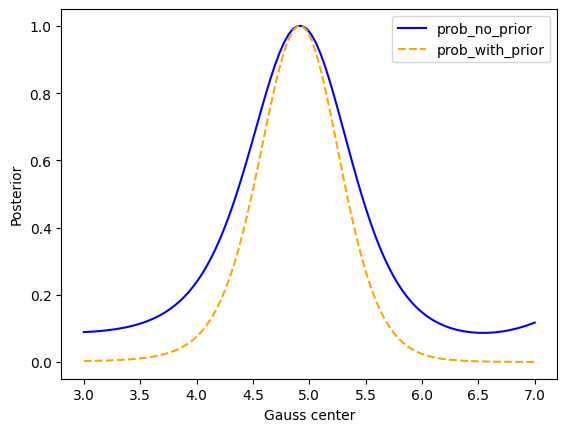

In [32]:
plt.figure()
plt.plot(gauss_center_grid, prob_no_prior, label="prob_no_prior",color="blue")
plt.plot(gauss_center_grid, prob_with_prior, label="prob_with_prior",color="orange",linestyle="--")
plt.xlabel("Gauss center")
plt.ylabel("Posterior")
plt.legend()

To keep following our pattern, here is the equivalent approach with MCMC.

In [33]:
def log_likelihood_case4(paras, data_obj):
    """
    Returns log-likelihood for case 4.
    We are adding a prior on gauss_amplitude and intercept here.
    """
    _gauss_center,_gauss_amplitude,_intercept = paras

    d,M,s,_ = intro_regularization_fm([_gauss_center], data_obj,gauss_width=gauss_width)
    model = np.dot(M, [_gauss_amplitude,_intercept])  # linear model prediction

    # Log-likelihood
    log_like = -0.5 * np.sum(((d - model) / s) ** 2)
    # adding the prior on gauss_amplitude and intercept.
    log_like += -0.5 * np.sum(((_gauss_amplitude - gauss_amplitude) / 0.001) ** 2)
    log_like += -0.5 * np.sum(((_intercept - intercept) / 0.001) ** 2)

    return  log_like


# MCMC setup
nwalkers = 50
nsteps = 2000

# Start walkers
paras_init = np.array([gauss_center,gauss_amplitude,intercept])
ndim = np.size(paras_init)
p0 = paras_init + 1e-2 * np.random.randn(nwalkers, ndim)
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_likelihood_case4, args=[data_obj])

# Run MCMC
sampler.run_mcmc(p0, nsteps, progress=True)
samples = sampler.get_chain(flat=True)


# Plot MCMC posterior as histogram
# Discard burn-in and extract chains
gauss_center_samples = samples[(nsteps//4*nwalkers)::, 0]
gauss_ampl_samples = samples[(nsteps//4*nwalkers)::, 1]
intercept_samples = samples[(nsteps//4*nwalkers)::, 2]
print("EMCEE gaussian center:", np.median(gauss_center_samples), "±", np.std(gauss_center_samples))
print("EMCEE gaussian amplitude:", np.median(gauss_ampl_samples), "±", np.std(gauss_ampl_samples))
print("EMCEE Intercept:", np.median(intercept_samples), "±", np.std(intercept_samples))

100%|██████████| 2000/2000 [00:02<00:00, 692.14it/s]

EMCEE gaussian center: 4.906146817041555 ± 0.3458790860843442
EMCEE gaussian amplitude: 8.000007410121588 ± 0.001007190305182658
EMCEE Intercept: 4.9999655988106 ± 0.0010039660700034403


And plotting the results. The MCMC posterior for gauss_center should match the BREADS posterior for gauss_center with regularization enabled. The BREADS posterior without regularization should be broader.

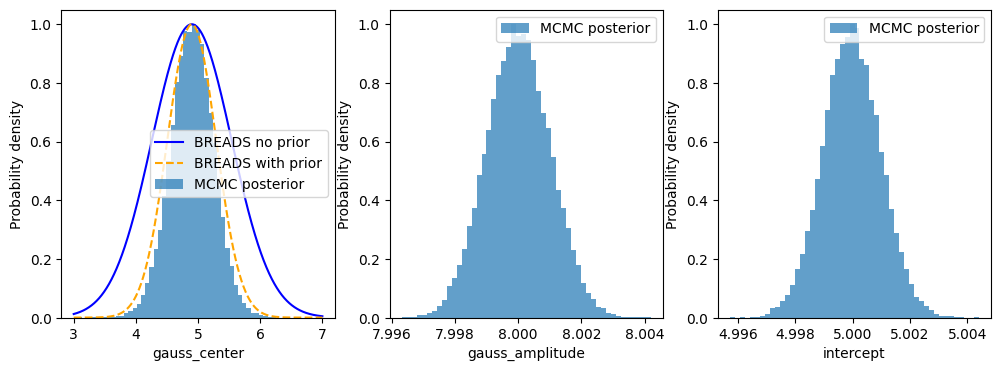

In [34]:
# Compute histogram
hist_vals_gauss_center,bin_edges_gauss_center = np.histogram(gauss_center_samples, bins=50, density=True)
hist_vals_gauss_ampl,bin_edges_gauss_ampl = np.histogram(gauss_ampl_samples, bins=50, density=True)
hist_vals_intercept,bin_edges_intercept = np.histogram(intercept_samples, bins=50, density=True)

# Normalize so the max is 1 (to match grid-search)
hist_vals_gauss_center /= np.max(hist_vals_gauss_center)
hist_vals_gauss_ampl /= np.max(hist_vals_gauss_ampl)
hist_vals_intercept /= np.max(hist_vals_intercept)

# Bin centers for plotting
bin_centers_gauss_center = 0.5 * (bin_edges_gauss_center[:-1] + bin_edges_gauss_center[1:])
bin_centers_gauss_ampl = 0.5 * (bin_edges_gauss_ampl[:-1] + bin_edges_gauss_ampl[1:])
bin_centers_intercept = 0.5 * (bin_edges_intercept[:-1] + bin_edges_intercept[1:])

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.bar(bin_centers_gauss_center, hist_vals_gauss_center, width=bin_edges_gauss_center[1] - bin_edges_gauss_center[0], alpha=0.7,label='MCMC posterior')
gauss_center_axis = np.linspace(gauss_center-2, gauss_center+2, 1000)
plt.plot(gauss_center_axis,np.exp(-(gauss_center_axis-best_fit1)**2/(2*((left_err1+right_err1)/2)**2)), label='BREADS no prior',color="blue")
plt.plot(gauss_center_axis,np.exp(-(gauss_center_axis-best_fit2)**2/(2*((left_err2+right_err2)/2)**2)), label='BREADS with prior',color="orange",linestyle="--")
plt.xlabel("gauss_center")
plt.ylabel("Probability density")
plt.legend()

plt.subplot(1,3,2)
plt.bar(bin_centers_gauss_ampl, hist_vals_gauss_ampl, width=bin_edges_gauss_ampl[1] - bin_edges_gauss_ampl[0], alpha=0.7,label='MCMC posterior')
plt.xlabel("gauss_amplitude")
plt.ylabel("Probability density")
plt.legend()

plt.subplot(1,3,3)
plt.bar(bin_centers_intercept, hist_vals_intercept, width=bin_edges_intercept[1] - bin_edges_intercept[0], alpha=0.7,label='MCMC posterior')
plt.xlabel("intercept")
plt.ylabel("Probability density")
plt.legend()